<a href="https://colab.research.google.com/github/Jormao2025/Data_Science_1/blob/main/Proyecto_Final_Data_Science_III_An%C3%A1lisis_Sentimiento_en_Tweets_sobre_Vacunas_contra_COVID_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis de Sentimiento en Tweets sobre Vacunas contra COVID-19

## 1- Introducción
La pandemia de COVID-19 generó un impacto significativo a nivel global, no solo en términos sanitarios sino también en la forma en que las personas intercambian información y opiniones a través de plataformas digitales. En este contexto, las redes sociales se convirtieron en uno de los principales espacios donde los usuarios expresaron percepciones, preocupaciones y opiniones respecto al desarrollo y distribución de las vacunas contra el virus.

Twitter, en particular, representa una fuente valiosa de información para el análisis de la opinión pública, ya que permite observar reacciones inmediatas frente a eventos de relevancia social. El análisis de estas publicaciones puede contribuir a comprender tendencias de percepción social, identificar preocupaciones comunes y evaluar el impacto de las campañas de comunicación relacionadas con la salud pública.

El Procesamiento de Lenguaje Natural (NLP) y las técnicas de Machine Learning permiten analizar grandes volúmenes de texto provenientes de redes sociales de manera automatizada. Una de las aplicaciones más relevantes dentro de este campo es el análisis de sentimiento, que permite identificar si un texto expresa una opinión positiva, negativa o neutral.

En este proyecto se utilizarán técnicas de procesamiento de lenguaje natural y aprendizaje automático para analizar tweets relacionados con las vacunas contra la COVID-19 y clasificar automáticamente el sentimiento presente en dichos mensajes.

## 2- Problema de negocio

Las redes sociales generan diariamente grandes volúmenes de información que reflejan la percepción y opinión de los usuarios frente a diferentes acontecimientos. Analizar manualmente este tipo de contenido resulta complejo debido a la cantidad de datos disponibles y a la velocidad con la que se producen nuevas publicaciones.

En el contexto de las vacunas contra la COVID-19, comprender la opinión de los usuarios puede aportar información relevante sobre la aceptación social de las campañas de vacunación y las percepciones de la población frente a distintos laboratorios y desarrollos farmacéuticos.

El desafío consiste en procesar y analizar automáticamente miles de publicaciones textuales para identificar el sentimiento asociado a cada mensaje, utilizando herramientas de análisis de texto y modelos de aprendizaje automático capaces de clasificar la polaridad de los tweets.

## 3- Objetivo general

Desarrollar un modelo de clasificación de sentimientos aplicado a tweets relacionados con las vacunas contra la COVID-19, utilizando técnicas de procesamiento de lenguaje natural y aprendizaje supervisado con el fin de identificar automáticamente la polaridad de las opiniones expresadas en las publicaciones.

## 4- Objetivos específicos

- Analizar la estructura y características del conjunto de datos utilizado en el estudio.

- Aplicar técnicas de preprocesamiento de texto para limpiar y normalizar el contenido de los tweets.

- Explorar patrones presentes en el texto mediante análisis de frecuencia de palabras, n-gramas y visualizaciones.

- Transformar los textos en representaciones numéricas mediante técnicas de vectorización como TF-IDF o Bag of Words.

- Entrenar un modelo de aprendizaje supervisado para clasificar los tweets según su sentimiento.

- Evaluar el desempeño del modelo utilizando métricas de clasificación y analizar los resultados obtenidos.

## 4- Origen de los datos
Origen de los datos

El conjunto de datos utilizado en este proyecto proviene del repositorio público Kaggle, específicamente del dataset denominado COVID-19 Vaccine Tweets with Sentiment Annotation https://www.kaggle.com/datasets/datasciencetool/covid19-vaccine-tweets-with-sentiment-annotation?resource=download.
Este dataset contiene una recopilación de tweets relacionados con diferentes vacunas contra la COVID-19, los cuales fueron anotados manualmente con información de sentimiento.

Los identificadores de los tweets fueron obtenidos a partir de un conjunto de datos desarrollado por Gabriel Preda, a partir del cual se recuperó el texto completo de cada publicación. El dataset incluye tweets vinculados a diversas vacunas desarrolladas durante la pandemia, entre ellas Pfizer/BioNTech, Moderna, Oxford/AstraZeneca, Sinopharm, Sinovac, Covaxin y Sputnik V.

Cada tweet posee una etiqueta de sentimiento que indica la polaridad del mensaje, codificada de la siguiente manera:

1 → sentimiento negativo

2 → sentimiento neutral

3 → sentimiento positivo

Esta información permite utilizar el conjunto de datos para tareas de clasificación supervisada, entrenando modelos capaces de identificar automáticamente el sentimiento de nuevas publicaciones en redes sociales.

## 5- Librerías utilizadas
Para el desarrollo del proyecto se utilizaron diversas librerías del ecosistema Python orientadas al análisis de datos, procesamiento de texto y aprendizaje automático.

Las principales herramientas utilizadas incluyen:

- Pandas y NumPy para manipulación y análisis de datos.

- Matplotlib y Seaborn para visualización de información.

- NLTK para tareas de procesamiento de lenguaje natural como tokenización, eliminación de stopwords y lematización.

- Scikit-learn para la implementación de técnicas de vectorización de texto y modelos de machine learning.

- WordCloud para la generación de visualizaciones de frecuencia de palabras.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install nltk
!pip install wordcloud

## 6- Carga y preparación del dataset

In [45]:
import requests

url = "https://github.com/Jormao2025/Data_Science_1/raw/refs/heads/main/covid-19_vaccine_tweets_with_sentiment1.csv"

response = requests.get(url)  # Hace una solicitud GET para obtener el contenido del archivo
print(response.text[:300])  # Imprime los primeros 300 caracteres del archivo para ver cómo está delimitado

df = pd.read_csv(url, sep=';', encoding='latin1')

df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()

temp = df['tweet_id,label,tweet_text'].str.split(',', n=2, expand=True)

df['tweet_id'] = temp[0]
df['label'] = temp[1]
df['tweet_text'] = temp[2]

df = df[['tweet_id','label','tweet_text']].copy()

df['label'] = pd.to_numeric(df['label'], errors='coerce')

df.dropna(inplace=True)

df = df[['tweet_text','label']].copy()

df.head()



tweet_id,label,tweet_text;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;
"1360342002961940483,1,""4,000 a day dying from the so called Covid-19 “vaccine” @DailyBeast reports. #vaccine #PfizerVaccine #Moderna  ";;;;;" """"https://t.co/p1nQWWZ


,tweet_text,label
0,"""4,000 a day dying from the so called Covid-19...",1
1,Pranam message for today manifested in Dhyan b...,2
2,"""Hyderabad-based ?@BharatBiotech? has sought f...",2
3,"""Confirmation that Chinese #vaccines """"""""""""""""d...",1
4,"""Lab studies suggest #Pfizer, #Moderna vaccine...",3


## 7- Análisis exploratorio de datos
En esta etapa se analiza la estructura del dataset, la distribución de las etiquetas de sentimiento y algunas características básicas del texto. Este análisis permite identificar posibles desbalances entre las clases y comprender mejor el contenido de los tweets.

### Distribución de sentimientos

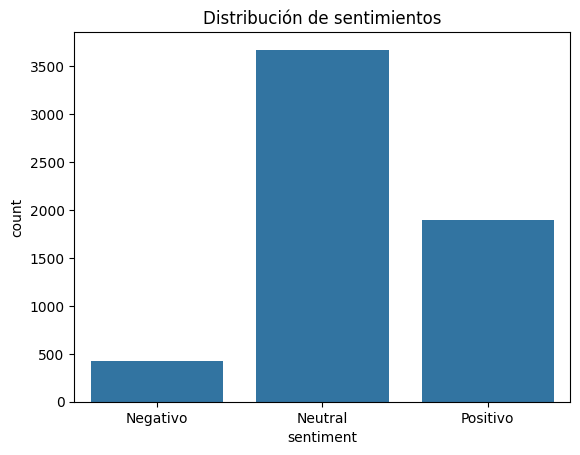

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

label_map = {1:'Negativo',2:'Neutral',3:'Positivo'}
df['sentiment'] = df['label'].map(label_map)

sns.countplot(x='sentiment', data=df)
plt.title("Distribución de sentimientos")
plt.show()

### Longitud de tweets

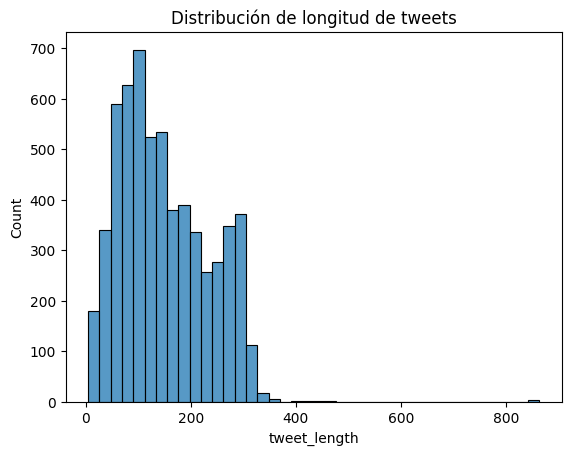

In [47]:
df['tweet_length'] = df['tweet_text'].astype(str).apply(len)

sns.histplot(df['tweet_length'], bins=40)
plt.title("Distribución de longitud de tweets")
plt.show()

## 8- Preprocesamiento NLP
En esta etapa se aplican técnicas de preprocesamiento de lenguaje natural con el objetivo de limpiar y normalizar los tweets. Este paso es fundamental para reducir ruido en el texto y mejorar la calidad de las representaciones numéricas que se utilizarán posteriormente en el modelo de clasificación.

Las principales tareas aplicadas incluyen:

- conversión a minúsculas

- eliminación de URLs

- eliminación de menciones y símbolos innecesarios

- eliminación de puntuación y números

- eliminación de stopwords

- lematización

### 8.1 Instalación e importación de librerías

In [54]:
!pip install nltk wordcloud -q

In [55]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

### 8.2 Descarga de recursos de NLTK

In [56]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### 8.3 Crear stopwords y lematizador

In [58]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

### 8.4 Aplicar función de limpieza

In [59]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)   # eliminar urls
    text = re.sub(r'@\w+', '', text)                      # eliminar menciones
    text = re.sub(r'#', '', text)                         # quitar símbolo hashtag
    text = re.sub(r'\d+', '', text)                       # quitar números
    text = text.translate(str.maketrans('', '', string.punctuation))  # quitar puntuación

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

### 8.5 Aplicar limpieza al dataset

In [62]:
df['clean_text'] = df['tweet_text'].apply(clean_text)

### 8.6 Verificar que la columna se creó bien

In [63]:
print(df.columns)
print(df[['tweet_text', 'clean_text']].head())

Index(['tweet_text', 'label', 'sentiment', 'tweet_length', 'clean_text'], dtype='object')
                                          tweet_text  \
0  "4,000 a day dying from the so called Covid-19...   
1  Pranam message for today manifested in Dhyan b...   
2  "Hyderabad-based ?@BharatBiotech? has sought f...   
3  "Confirmation that Chinese #vaccines """"""""d...   
4  "Lab studies suggest #Pfizer, #Moderna vaccine...   

                                          clean_text  
0  day dying called covid âvaccineâ report va...  
1  pranam message today manifested dhyan truth lo...  
2  hyderabadbased sought fund government ramp pro...  
3  confirmation chinese vaccine donât high prot...  
4  lab study suggest pfizer moderna vaccine prote...  


## 9- Visualización de texto

### 9.1 Nube de palabras general

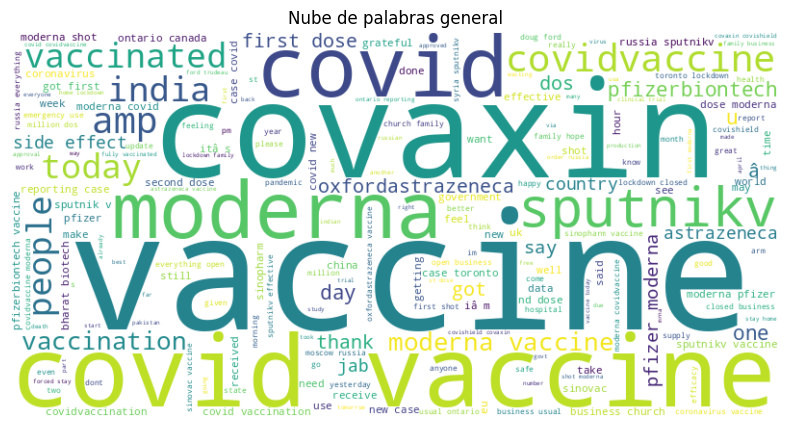

In [64]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_all = " ".join(df['clean_text'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_all)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras general")
plt.show()

### 9.2 Nube de palabras por sentimiento

In [65]:
label_map = {1: 'Negativo', 2: 'Neutral', 3: 'Positivo'}
df['sentiment'] = df['label'].map(label_map)

#### Negativo

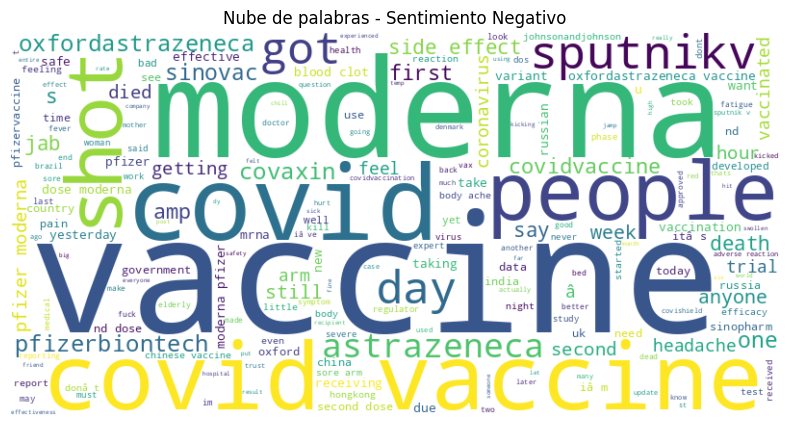

In [66]:
text_neg = " ".join(df[df['sentiment'] == 'Negativo']['clean_text'].dropna())

wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(text_neg)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras - Sentimiento Negativo")
plt.show()

#### Neutral

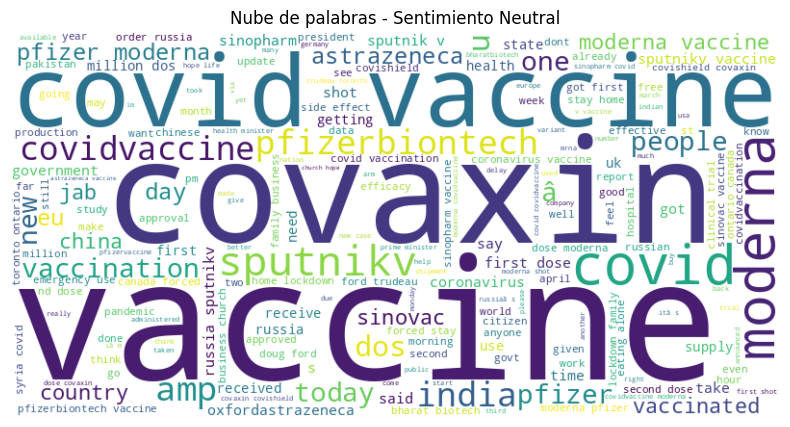

In [67]:
text_neu = " ".join(df[df['sentiment'] == 'Neutral']['clean_text'].dropna())

wordcloud_neu = WordCloud(width=800, height=400, background_color='white').generate(text_neu)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neu, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras - Sentimiento Neutral")
plt.show()

#### Positivo

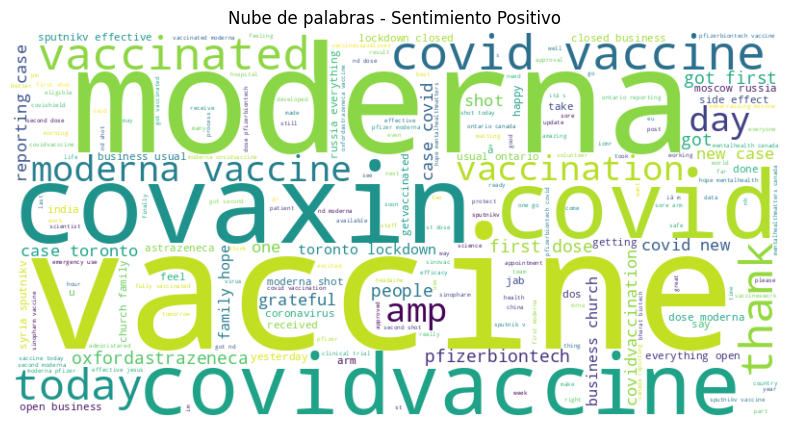

In [68]:
text_pos = " ".join(df[df['sentiment'] == 'Positivo']['clean_text'].dropna())

wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(text_pos)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras - Sentimiento Positivo")
plt.show()

## 10- N-gramas

Además del análisis de frecuencia de palabras individuales, se analizaron combinaciones de palabras consecutivas (n-gramas), ya que estas pueden aportar mayor contexto semántico que los términos aislados.

### 10. 1 Bigramas más frecuentes

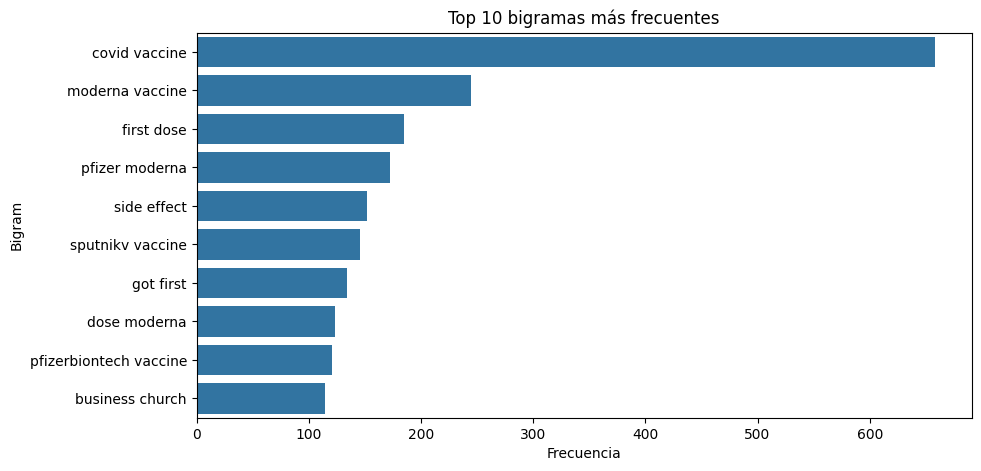

In [69]:
from sklearn.feature_extraction.text import CountVectorizer
import seaborn as sns

bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10)
X_bigrams = bigram_vectorizer.fit_transform(df['clean_text'])

sum_words = X_bigrams.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in bigram_vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

bigram_df = pd.DataFrame(words_freq, columns=['Bigram', 'Frecuencia'])

plt.figure(figsize=(10,5))
sns.barplot(data=bigram_df, x='Frecuencia', y='Bigram')
plt.title('Top 10 bigramas más frecuentes')
plt.show()

## 11- Vectorización TF-IDF

Con el fin de transformar los textos procesados en una representación numérica utilizable por modelos de machine learning, se aplicó la técnica TF-IDF (Term Frequency - Inverse Document Frequency). Esta técnica permite asignar mayor peso a las palabras más relevantes dentro de cada documento y reducir la importancia de términos muy frecuentes en todo el corpus.

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['label']

print(X.shape)
print(y.shape)

(5990, 5000)
(5990,)


## 12- División en entrenamiento y prueba

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4792, 5000)
X_test: (1198, 5000)
y_train: (4792,)
y_test: (1198,)


## 13- Modelo de clasificación

Para la clasificación de sentimientos se utilizó un modelo de Regresión Logística, ya que constituye una alternativa simple, interpretable y ampliamente utilizada en tareas de clasificación de texto cuando se combinan representaciones TF-IDF con aprendizaje supervisado.

### 13.1 Entrenamiento del modelo

In [75]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 14- Evaluación del modelo

### 14.1 Predicciones

In [77]:
y_pred = model.predict(X_test)

### 14.2 Métricas

In [78]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7095158597662772

Reporte de clasificación:

              precision    recall  f1-score   support

           1       0.40      0.02      0.04        84
           2       0.72      0.88      0.79       734
           3       0.68      0.52      0.59       380

    accuracy                           0.71      1198
   macro avg       0.60      0.48      0.48      1198
weighted avg       0.69      0.71      0.68      1198



### 14.3 Matriz de confusión

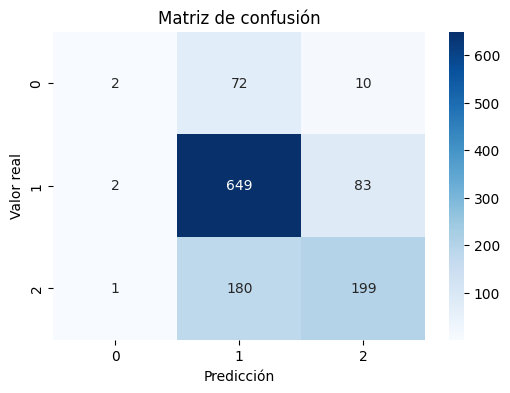

In [79]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

## 15- Interpretación de resultados

A partir de las métricas obtenidas fue posible evaluar la capacidad del modelo para clasificar correctamente el sentimiento expresado en los tweets. La accuracy ofrece una visión general del desempeño, mientras que métricas como precision, recall y F1-score permiten analizar el comportamiento del modelo para cada clase de sentimiento.

La matriz de confusión complementa este análisis al mostrar de manera visual los aciertos y errores de clasificación, permitiendo identificar si el modelo presenta dificultades para distinguir alguna categoría particular.

# Conclusiones

En este proyecto se aplicaron técnicas de procesamiento de lenguaje natural y aprendizaje automático para analizar el sentimiento en tweets relacionados con las vacunas contra la COVID-19. El proceso incluyó etapas de limpieza y normalización del texto, análisis exploratorio, generación de representaciones numéricas mediante TF-IDF y entrenamiento de un modelo de clasificación supervisada.

Los resultados obtenidos muestran que el uso combinado de técnicas de NLP y modelos tradicionales de machine learning permite analizar grandes volúmenes de datos textuales y detectar automáticamente la polaridad de las opiniones expresadas en redes sociales.

Como posibles líneas de mejora futura, podría evaluarse el desempeño de otros algoritmos de clasificación o incorporar arquitecturas más avanzadas de deep learning, como redes neuronales o modelos basados en Transformers, con el objetivo de comparar resultados y analizar posibles mejoras en la capacidad predictiva.